lstm ids 2018

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import glob
import gc

path = '/kaggle/input/datasets/solarmainframe/ids-intrusion-csv/*.csv'
files = glob.glob(path)
device = 'cuda' if torch.cuda.is_available() else cpu
df_list = []
for file in files:
    temp_df = pd.read_csv(file, low_memory=False)
    temp_df = temp_df[temp_df['Label'] != 'Label']
    
    if 'Timestamp' in temp_df.columns:
        t = pd.to_datetime(temp_df['Timestamp'], errors='coerce')
        temp_df['Hour'] = t.dt.hour.fillna(0).astype(np.int8)
        temp_df['Minute'] = t.dt.minute.fillna(0).astype(np.int8)
        temp_df.drop(columns=['Timestamp'], inplace=True)
    temp_df = temp_df.sample(frac=0.1, random_state=42)
    for col in temp_df.select_dtypes(include=['float64']).columns:
        temp_df[col] = temp_df[col].astype(np.float32)

    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
del df_list 
gc.collect()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df = df[numeric_cols + ['Label']]

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
del df
gc.collect()


class IDS_Dataset(Dataset):
    def __init__(self,df,scaler=None, le=None):
        X = df.drop('Label', axis=1).values
        y = df['Label'].values

        if scaler is None:
            self.scaler = StandardScaler()
            self.X = self.scaler.fit_transform(X)
        else:
            self.scaler = scaler
            self.X = self.scaler.transform(X)
            
        if le is None:
            self.le = LabelEncoder()
            self.y = self.le.fit_transform(y)
        else:
            self.le = le
            self.y = self.le.transform(y)

        self.X = torch.tensor(self.X,dtype = torch.float32)
        self.y = torch.tensor(self.y,dtype = torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self,idx):
        return self.X[idx],self.y[idx]

train_dataset = IDS_Dataset(train_df)

test_dataset = IDS_Dataset(test_df, scaler=train_dataset.scaler, le=train_dataset.le)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    drop_last=True,
    num_workers=4,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    drop_last=False,
    num_workers=4,
    pin_memory=True
)

class IDS_LSTM(nn.Module):
    def __init__(self,input_size=3,hidden_size=64,num_layers=2,num_classes=3):
        super(IDS_LSTM,self).__init__()
        self.hidden_size=hidden_size
        self.num_layers=num_layers
        self.lstm = nn.LSTM(input_size,hidden_size,num_layers,batch_first=True)
        self.fc = nn.Linear(hidden_size,num_classes)
    def forward(self,x):
        x = x.unsqueeze(1)
        out, (h_n,c_n) = self.lstm(x)
        out = self.fc(out[:,-1,:])
        return out

model = IDS_LSTM()
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

for epoch in range(2):
    for i,(batch_X,batch_y) in enumerate(train_loader):
        batch_X,batch_y=batch_X.to(device),batch_y.to(device)
        optimizer.zero_grad()

        logits = model(batch_X)
        loss = criterion(logits,batch_y)

        loss.backward()
        optimizer.step()

        if i % 1000 == 0:
            preds = torch.argmax(logits,dim=1)
            acc = (preds == batch_y).float().mean()
            print('loss',loss.item(),'train',acc.item())

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for x,y in test_loader:
        x,y = x.to(device),y.to(device)
        outp = model(x)
        preds = torch.argmax(outp,dim=1)
        total += y.size(0)
        correct += (preds == y).sum().item()
    print('test',100*correct/total)

/tmp/ipykernel_57/1932618745.py:24: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  t = pd.to_datetime(temp_df['Timestamp'], errors='coerce')
/tmp/ipykernel_57/1932618745.py:24: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  t = pd.to_datetime(temp_df['Timestamp'], errors='coerce')
/tmp/ipykernel_57/1932618745.py:24: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  t = pd.to_datetime(temp_df['Timestamp'], errors='coerce')
/tmp/ipykernel_57/1932618745.py:24: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warni

loss 1.1089556217193604 train 0.0
loss 0.18445992469787598 train 0.921875
loss 0.09957551211118698 train 0.94140625
loss 0.0958242118358612 train 0.9609375
loss 0.08734582364559174 train 0.9453125
loss 0.04545295983552933 train 0.984375
test 98.09907218116057


In [16]:
from sklearn.metrics import roc_auc_score

all_probs = []
all_labels = []

with torch.no_grad():
    for x,y in test_loader:
        x,y = x.to(device),y.to(device)
        logits = model(x)
        probs = F.softmax(logits,dim=1)
        all_probs.append(probs.cpu())
        all_labels.append(y.cpu())

all_probs = torch.cat(all_probs).numpy()
all_labels = torch.cat(all_labels).numpy()

present_classes = np.unique(all_labels)
filtered_probs = all_probs[:, present_classes]

if len(present_classes) == 2:
    roc_auc = roc_auc_score(all_labels, filtered_probs[:, 1])
else:
    filtered_probs = filtered_probs / filtered_probs.sum(axis=1, keepdims=True)
    roc_auc = roc_auc_score(all_labels, filtered_probs, multi_class='ovr', average='macro')

print(f'RA: {roc_auc:.6f}')


RA: 0.994520


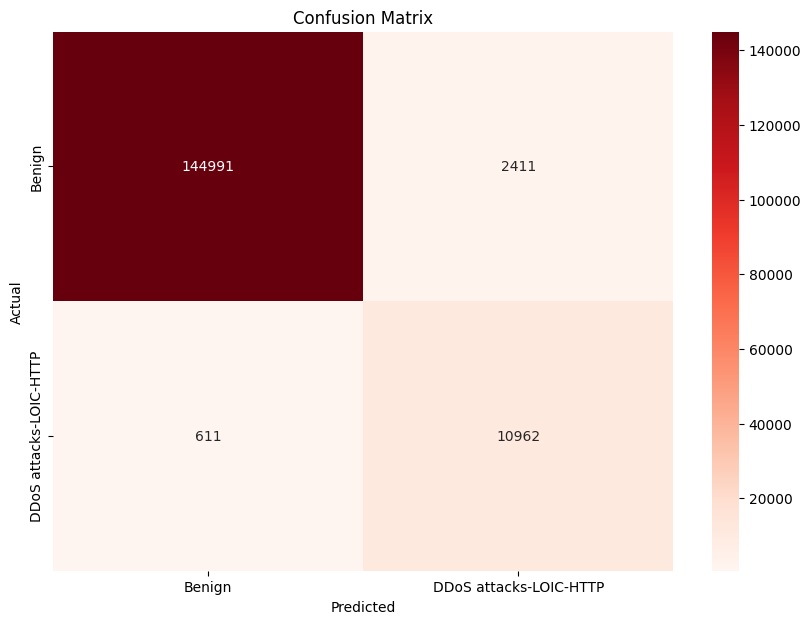


Отчет по классификации:
                        precision    recall  f1-score   support

                Benign       1.00      0.98      0.99    147402
DDoS attacks-LOIC-HTTP       0.82      0.95      0.88     11573

              accuracy                           0.98    158975
             macro avg       0.91      0.97      0.93    158975
          weighted avg       0.98      0.98      0.98    158975



In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = model(x)
        preds = torch.argmax(logits, dim=1)
        
        y_true.extend(y.numpy())
        y_pred.extend(preds.cpu().numpy())

present_classes = np.unique(y_true)
class_names = train_dataset.le.inverse_transform(present_classes)

cm = confusion_matrix(y_true, y_pred, labels=present_classes)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nОтчет по классификации:")
print(classification_report(y_true, y_pred, target_names=class_names))
